# ANALISIS ESTADISTICO DE DATASET : ECOMMERCE CHURN
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/upam22/ecommerce-customer-churn-data)

# AUTOR : César Mayta

# PASO 1 - IMPORTAMOS LIBRERIAS

In [ ]:
!pip install pyjanitor

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import janitor
import missingno

# PASO 2 - EJECUTAMOS PANDAS MISSING EXTENSION NOTEBOOK

In [34]:
%run '/content/pandas_missing_extension.ipynb'

# PASO 3 - CARGAMOS DATASET

In [35]:
data_df = pd.read_csv('/content/ecom_data.csv')
data_df.head(2)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121


# PASO 4 - EDA

In [36]:
data_df.dtypes

,0
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


In [37]:
data_df.dtypes.value_counts()

,count
int64,8
float64,7
object,5


In [32]:
data_df.shape

(5630, 20)

In [38]:
data_df.drop('CustomerID',axis=1,inplace=True)

# PASO 5 - TRATAMIENTO DE DATOS FALTANTES

In [39]:
data_df.missing.number_missing()

1856

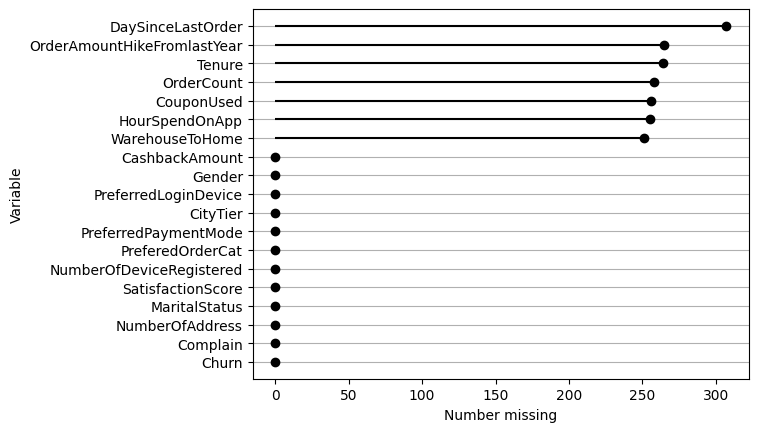

In [40]:
data_df.missing.missing_variable_plot()

<Axes: >

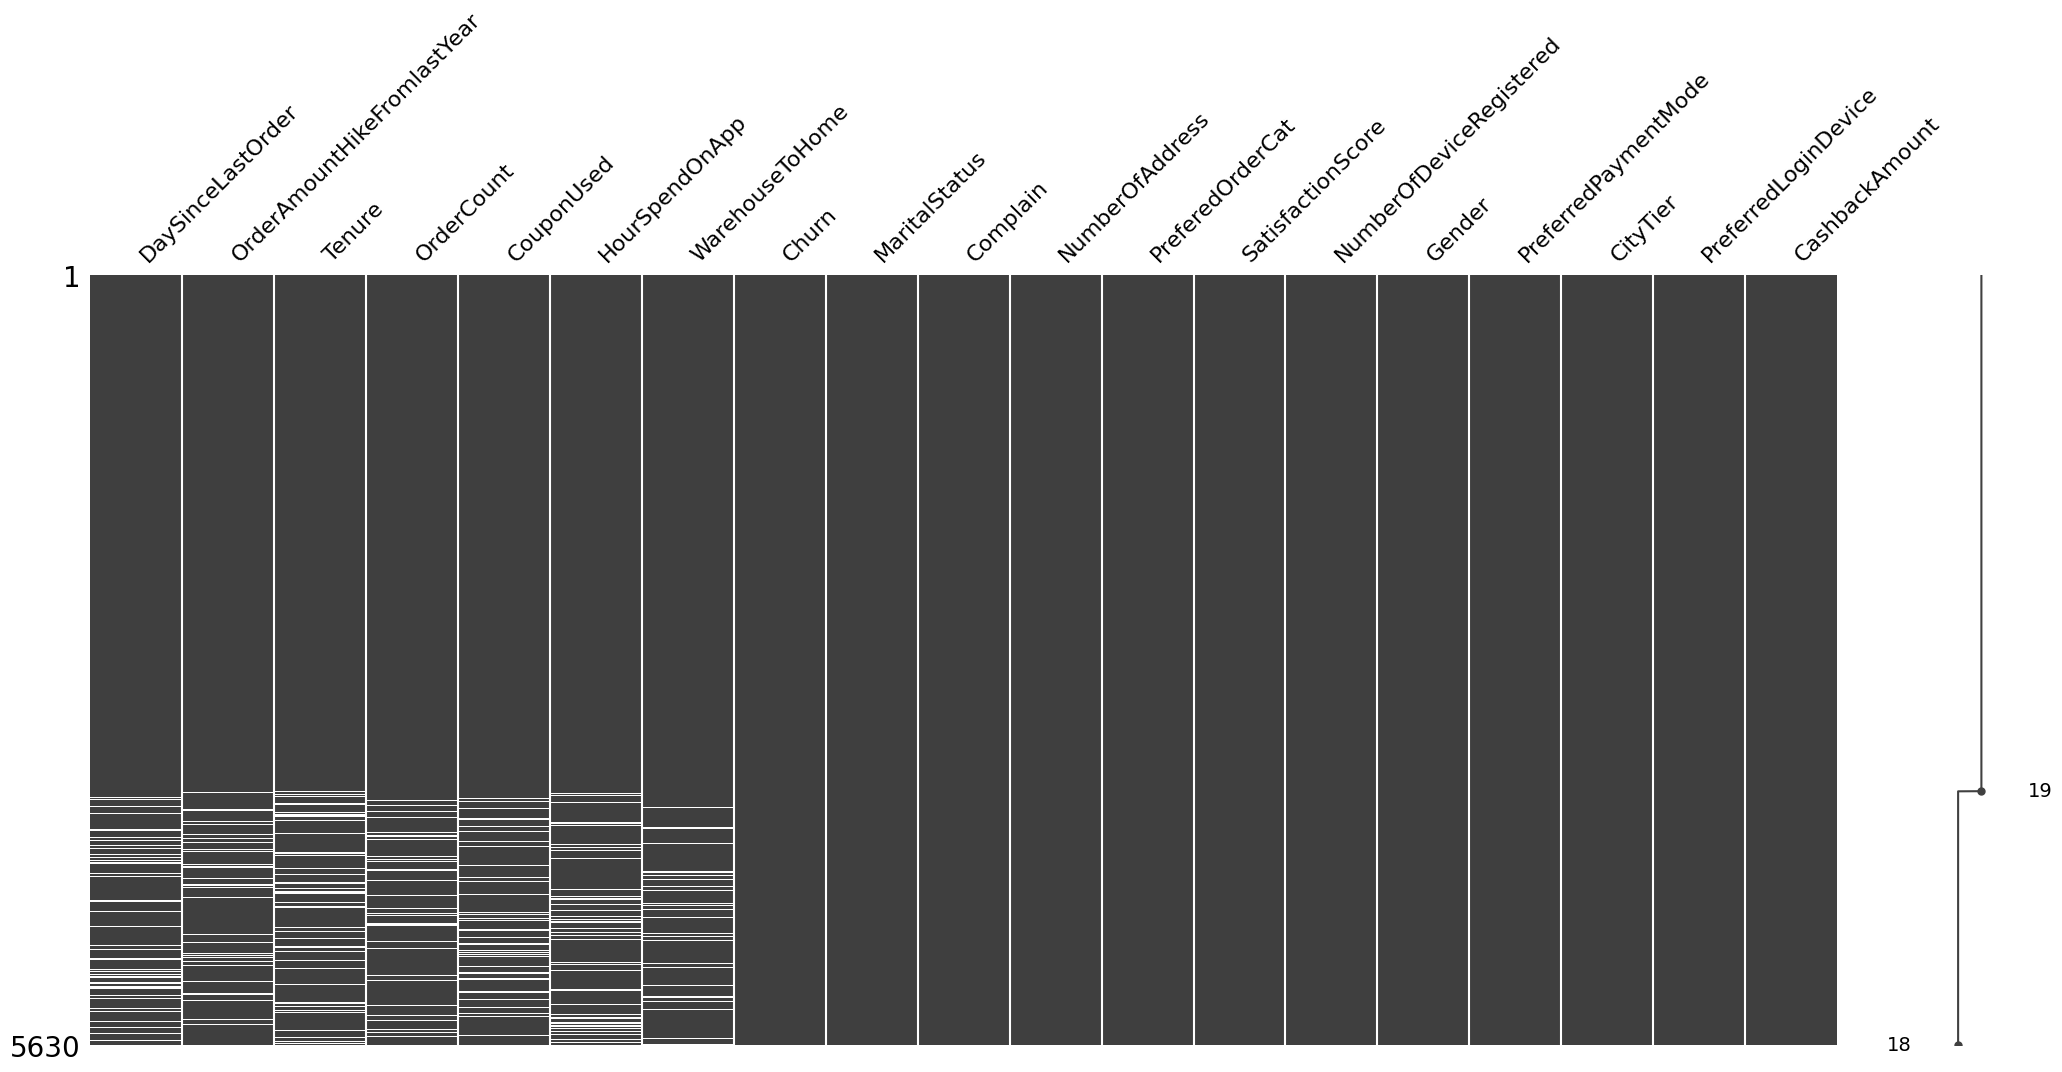

In [41]:

(
    data_df.missing.sort_variables_by_missingness()
    .pipe(
        missingno.matrix,sort='descending'
    )
)

In [42]:
data_df.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

## CAMBIAMOS LA NOMENCLATURA DE COLUMNAS

In [43]:
data_df_raw = (
    data_df.clean_names(
        case_type="snake"
    )
)
data_df_raw.head(2)

,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121


In [44]:
data_df_raw.columns

Index(['churn', 'tenure', 'preferred_login_device', 'city_tier',
       'warehouse_to_home', 'preferred_payment_mode', 'gender',
       'hour_spend_on_app', 'number_of_device_registered',
       'prefered_order_cat', 'satisfaction_score', 'marital_status',
       'number_of_address', 'complain', 'order_amount_hike_fromlast_year',
       'coupon_used', 'order_count', 'day_since_last_order',
       'cashback_amount'],
      dtype='object')

## Imputación de day_since_last_order

In [46]:
missing_variable = 'day_since_last_order'

In [48]:
data_df_raw[missing_variable].mean()

4.543490512868683

## IMPUTACIÓN POR  MEDIA

In [54]:
data_df_clean_mean = data_df_raw.copy()
data_df_clean_mean['day_since_last_order'] = data_df_clean_mean['day_since_last_order'].fillna(data_df_clean_mean['day_since_last_order'].mean())
print(f" media original : {data_df_raw['day_since_last_order'].mean()} | media sin nulos : {data_df_clean_mean['day_since_last_order'].mean()}")


 media original : 4.543490512868683 | media sin nulos : 4.543490512868684


## IMPUTACIÓN POR MEDIANA

In [55]:
data_df_clean_median = data_df_raw.copy()
data_df_clean_median['day_since_last_order'] = data_df_clean_median['day_since_last_order'].fillna(data_df_clean_median['day_since_last_order'].median())
print(f" media original : {data_df_raw['day_since_last_order'].median()} | media sin nulos : {data_df_clean_median['day_since_last_order'].median()}")

 media original : 3.0 | media sin nulos : 3.0


## IMPUTACIÓN POR MODA

In [56]:
data_df_clean_mode = data_df_raw.copy()
data_df_clean_mode['day_since_last_order'] = data_df_clean_mode['day_since_last_order'].fillna(data_df_clean_mode['day_since_last_order'].mode())
print(f" media original : {data_df_raw['day_since_last_order'].mode()} | media sin nulos : {data_df_clean_mode['day_since_last_order'].mode()}")

 media original : 0    3.0
Name: day_since_last_order, dtype: float64 | media sin nulos : 0    3.0
Name: day_since_last_order, dtype: float64


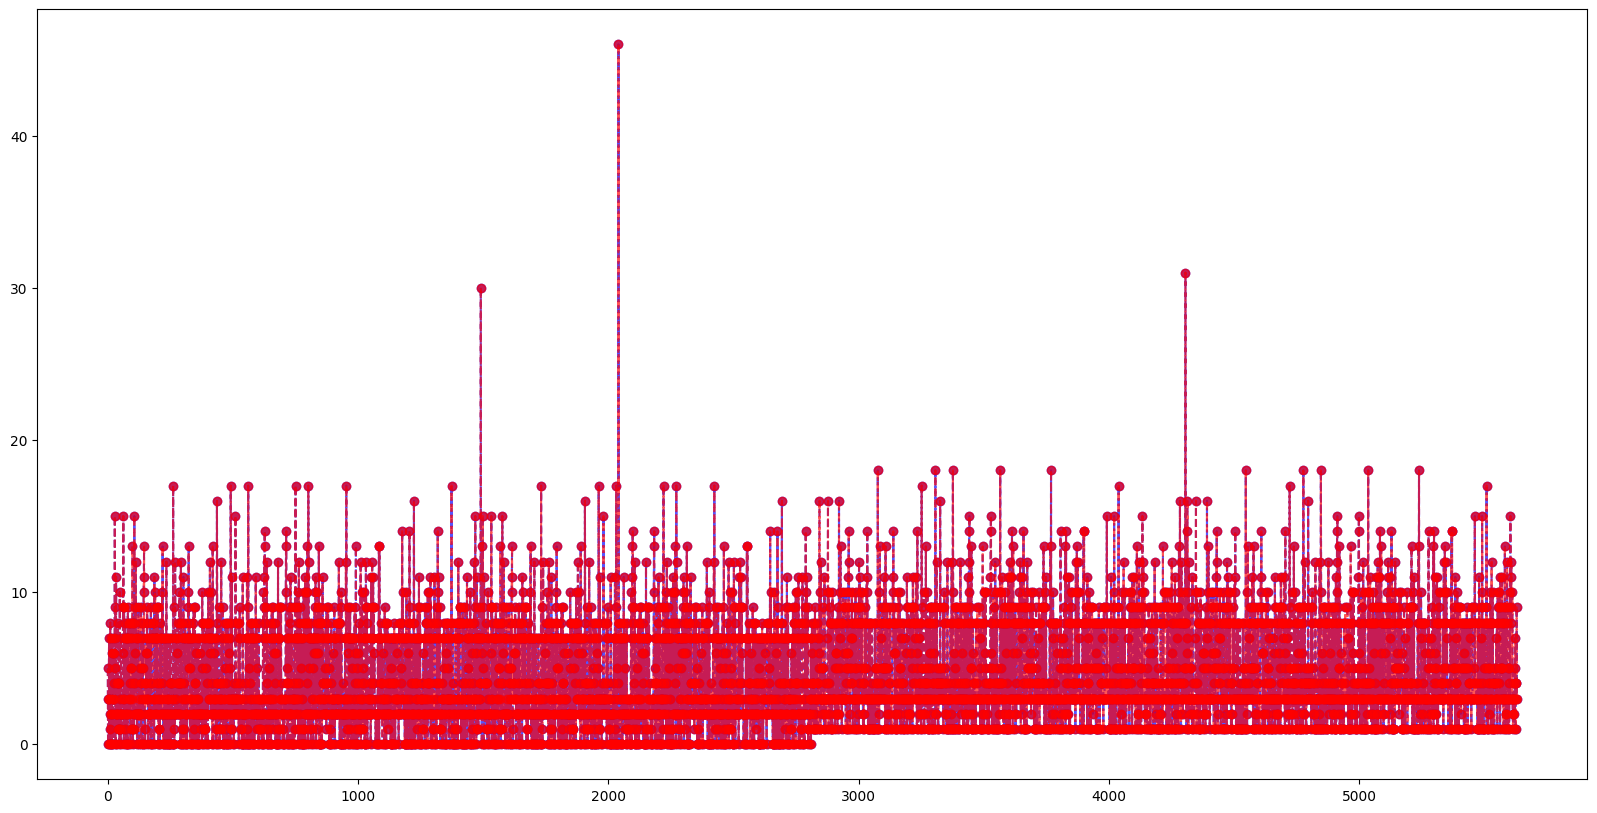

In [58]:
plt.figure(figsize=(20,10))
data_df_raw['day_since_last_order'].plot(color='blue',marker='o',alpha=6/9,linestyle='dashed')
data_df_clean_median['day_since_last_order'].plot(color='red',marker='o',alpha=6/9,linestyle='dashed')
plt.show()

In [59]:
data_df_clean = data_df_clean_median

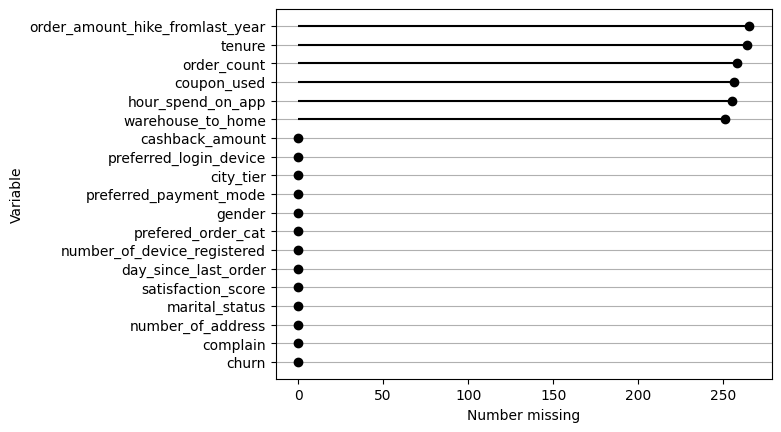

In [60]:
data_df_clean.missing.missing_variable_plot()